In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# the sea born is used to make easy of graph 



In [40]:
url="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749"
df=pd.read_csv(url)

In [41]:
df.head(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
5,KP281,20,Female,14,Partnered,3,3,32973,66
6,KP281,21,Female,14,Partnered,3,3,35247,75
7,KP281,21,Male,13,Single,3,3,32973,85
8,KP281,21,Male,15,Single,5,4,35247,141
9,KP281,21,Female,15,Partnered,2,3,37521,85


In [42]:
df.info()
# this gives the datatypes of all rows

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Product        180 non-null    str  
 1   Age            180 non-null    int64
 2   Gender         180 non-null    str  
 3   Education      180 non-null    int64
 4   MaritalStatus  180 non-null    str  
 5   Usage          180 non-null    int64
 6   Fitness        180 non-null    int64
 7   Income         180 non-null    int64
 8   Miles          180 non-null    int64
dtypes: int64(6), str(3)
memory usage: 12.8 KB


In [43]:
df.describe()
# this give the mean,median all other statistical forms

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [44]:
# we need to check if any data is missing
df.isnull()
df.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [45]:
# which is the most popular produt
df["Product"].value_counts()
# as the number of persons are large

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [46]:
# who buys more treadmils

df["Gender"].value_counts()

Gender
Male      104
Female     76
Name: count, dtype: int64

In [47]:
df["MaritalStatus"].value_counts()

MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

In [48]:
# Uni variate Analysis
# average age of costumers
# what is the max age of costumers
# which age group buys most treadmils
# single variable 

<Axes: xlabel='Product', ylabel='count'>

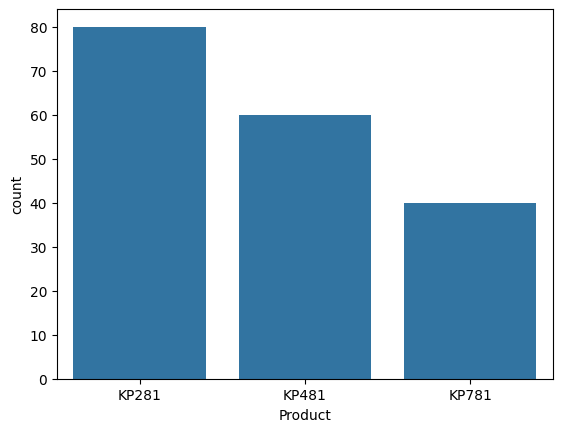

In [49]:
sns.countplot(x="Product",data=df)
# here countplot is used to draw a graph between frequencies

<Axes: xlabel='Age', ylabel='Count'>

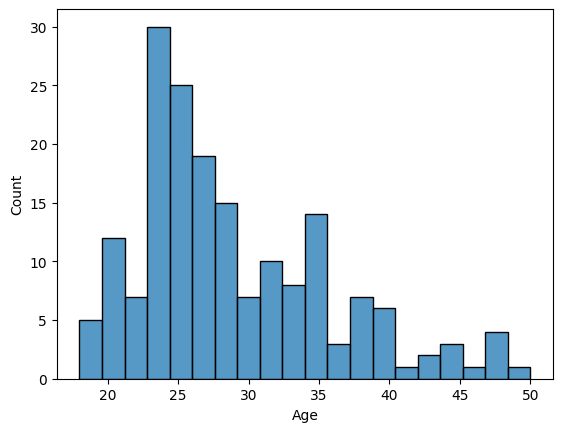

In [50]:
sns.histplot(df["Age"],bins=20)
# we can conclude that maximum age group is 25

<Axes: xlabel='Income', ylabel='Count'>

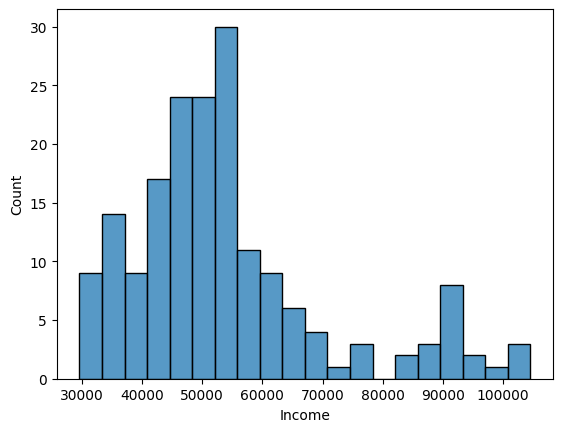

In [51]:
# which income group buys treadmils
sns.histplot(df["Income"],bins=20)
# ie 50,000

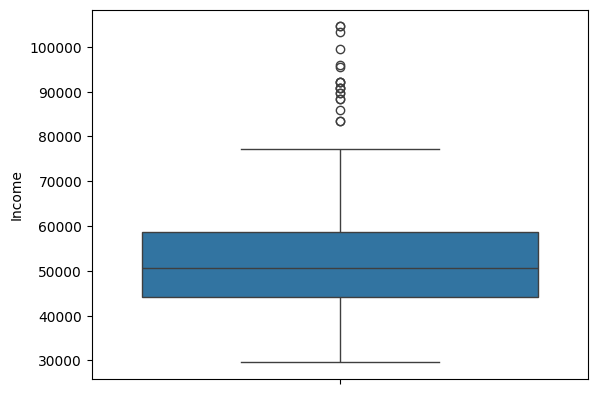

In [52]:
sns.boxplot(df["Income"])
plt.show()

In [53]:
# here circles are outliers
# the line is the mean of data


In [54]:
print("mean income",df["Income"].mean())
print("median income",df["Income"].median())


mean income 53719.57777777778
median income 50596.5


In [ ]:
#  Bivariate Analysis
#  relation ship between two variables
#  income and product
#  does age influence the miles run by the costumer
#  does male and female can buy different kind of products

<Axes: xlabel='Product', ylabel='count'>

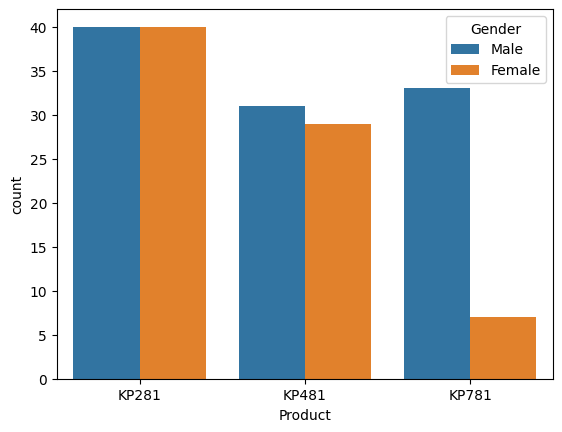

In [ ]:
# does age influence the miles run by the costumer
sns.countplot(x="Product",hue="Gender",data=df)
# categorical vs categarical

<Axes: xlabel='Product', ylabel='Age'>

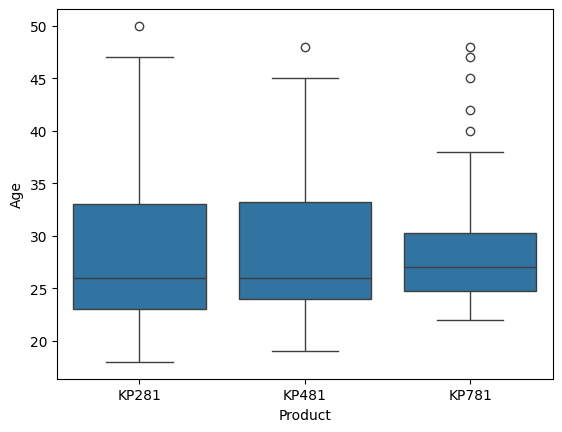

In [ ]:
# age vs product
sns.boxplot(x="Product",y="Age",data=df)

In [ ]:
# correlational analysis this will help us with all the combinations
# measures the strength and direction of relation ship between  variables
# only numericals
# correlation-matrix:correlation matrix is given
# this can be done by heat map function

In [ ]:
# +1 shows a perfect relation
# 0.7 to 0.9 strong relation
# 0.4 to 0.6 moderate
# 0.1 to 0.3 weak
# negative no relation


<Axes: >

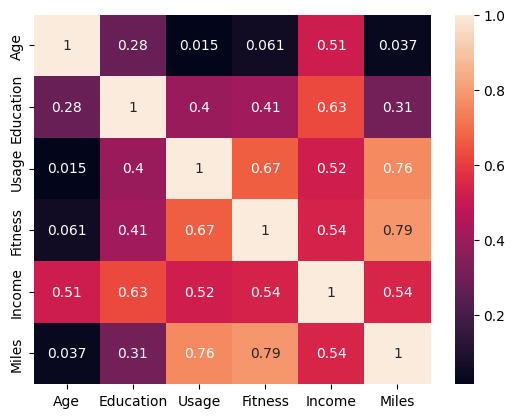

In [64]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [66]:
# probaility of single event is marginal probability
pd.crosstab(df["Product"],columns="probability",normalize=True)

col_0,probability
Product,
KP281,0.444444
KP481,0.333333
KP781,0.222222


In [ ]:
# what is the average age of group
# what is their income level
# how fit are they
# how many miles they can run
# how frequently they use treadmil

In [68]:
pd.crosstab(df["Gender"],df["Product"],normalize="index")

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308


In [70]:
df.groupby("Product")[["Age","Income","Education"]].mean()

,Age,Income,Education
Product,,,
KP281,28.55,46418.025,15.037500
KP481,28.90,48973.650,15.116667
KP781,29.10,75441.575,17.325000
